In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import torch
import os
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer
from dictionary_learning.mask_scae import SCAESuite, MergedSCAESuite # Your SCAESuite class
from datasets import load_dataset
from dictionary_learning.buffer import chunk_and_tokenize
from interp.interp_utils_new import (
    load_tokenized_dataset,
    collect_activations_and_tokens,
    generate_feature_dashboard
)

torch.set_grad_enabled(False)

# --- Configuration ---
MODEL_NAME = "EleutherAI/pythia-70m"
PATH_TO_PILE = "/root/dictionary_learning/pile-uncopyrighted"
# For local pile, you might need to specify data_files if it's a collection of .jsonl.gz
# e.g., data_files = {"train": ["/path/to/pile/train/00.jsonl.gz", ...]}
# For HF streaming, data_files can be None.
DATA_FILES = None # Set to list of local file paths if using local pile and not streaming
STREAM_PILE = True # If True, streams from HF. If False and DATA_FILES is None, loads non-streamed from HF.
                   # If DATA_FILES is set, STREAM_PILE=True will stream from those local files.
SEQ_LEN = 128
NUM_SAMPLES_TO_LOAD = 5000 # How many sequences to prepare from the dataset
NUM_SAMPLES_TO_PROCESS = 5000 # How many sequences to run through the suite for activations (max_batches_to_process * batch_size)
BATCH_SIZE_COLLECT = 64
OUTPUT_ACTIVATIONS_DIR = "output_activations_pile"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

/root/dictionary_learning/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [133]:
# --- Initialize Model and Tokenizer ---
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE, dtype=torch.bfloat16)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

suite = SCAESuite.from_pretrained(
    repo_id="jacobcd52/pythia-70m_k16_mask0.0001_fact_fvu0.1_fvu_sparse1.0_fvu1.0_lr0.0005",
    model=model,
    device=DEVICE,
    dtype=torch.bfloat16
)

print(f"Using device: {DEVICE}")
os.makedirs(OUTPUT_ACTIVATIONS_DIR, exist_ok=True)

Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Using device: cuda


In [3]:
raw_dataset = load_dataset(
    PATH_TO_PILE,
    split=f"train[:1%]",
).shuffle(seed=42)

tokenized_dataset = chunk_and_tokenize(
    dataset=raw_dataset,
    tokenizer=tokenizer,
    text_key="text",
    max_length=SEQ_LEN,
    num_proc=max(1, os.cpu_count() // 2),
    load_from_cache_file=True
)

if len(tokenized_dataset) > NUM_SAMPLES_TO_PROCESS:
    dataset_to_process = tokenized_dataset.select(range(NUM_SAMPLES_TO_PROCESS))
else:
    dataset_to_process = tokenized_dataset

Filter (num_proc=48): 100%|██████████| 58992/58992 [00:00<00:00, 64994.78 examples/s]


In [141]:
toks_list = []
iterable_dataset = iter(dataset_to_process)
for _ in range(64):
    toks_list.append(next(iterable_dataset)['input_ids'])
toks = torch.stack(toks_list[:32], dim=0)
toks_test = torch.stack(toks_list[32:], dim=0)


layer = 3
ae = suite.module_dict[f'attn_{layer}'].ae
hook_pt = f'blocks.{layer}.hook_attn_out'
_, cache = model.run_with_cache(toks, return_type="loss", names_filter=[hook_pt])
act = cache[hook_pt]
f = ae.encode(act)
recons = ae.decode(f)
fvu = (act - recons).pow(2).sum() / (act - act.mean(dim=[0, 1])).pow(2).sum()

print("SAE FVU: ", fvu)

_, cache_test = model.run_with_cache(toks_test, return_type="loss", names_filter=[hook_pt])
act_test = cache_test[hook_pt]

# Compute PCA on training activations
q = 16
U, S, V = torch.pca_lowrank(act.float().reshape(-1, act.shape[-1]), q=q)
V = V.to(act.dtype)
# Project test activations onto PCA components
act_test_flat = act_test.reshape(-1, act_test.shape[-1])
act_test_proj = act_test_flat @ V
# Compute variance explained
total_var = (act_test_flat - act_test_flat.mean(dim=[0, 1])).pow(2).sum()
explained_var = (act_test_proj - act_test_proj.mean(dim=[0, 1])).pow(2).sum()
print(f"FVU of top {q} PCA components: {1 - explained_var/total_var:.3f}")

SAE FVU:  tensor(0.2305, device='cuda:0', dtype=torch.bfloat16)
FVU of top 16 PCA components: 0.523


In [26]:
# merged_suite = MergedSCAESuite(model, suite)
# y_dict, f_dict, x_dict = merged_suite.forward(toks, temperature=0.0, runtime_use_sparse_connections_override=False)
# t = f_dict['attn_2'].topk(128, dim=-1).values
# t_flat = t.reshape(-1, t.shape[-1])

# import matplotlib.pyplot as plt
# for i in range(80):
#     plt.plot(t_flat[i*100].float().detach().cpu().numpy(), color='blue', alpha=0.1)

In [175]:
# --- Collect Activations ---
# Determine the number of batches to process
max_batches = NUM_SAMPLES_TO_PROCESS // BATCH_SIZE_COLLECT

# # Collect for sparse_false mode
# print("Starting activation collection for sparse_false mode...")
# collect_activations_and_tokens(
#     suite=suite,
#     model=model,
#     tokenizer=tokenizer,
#     dataset=dataset_to_process,
#     device=DEVICE,
#     output_dir=OUTPUT_ACTIVATIONS_DIR,
#     run_mode_sparse=False,
#     batch_size=BATCH_SIZE_COLLECT,
#     max_batches_to_process=max_batches
# )
# print("Finished activation collection for sparse_false mode.")

# Collect for sparse_true mode
print("\\nStarting activation collection for sparse_true mode...")
collect_activations_and_tokens(
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    dataset=dataset_to_process,
    device=DEVICE,
    output_dir=OUTPUT_ACTIVATIONS_DIR,
    run_mode_sparse=True,
    batch_size=BATCH_SIZE_COLLECT,
    max_batches_to_process=max_batches
)
print("Finished activation collection for sparse_true mode.")

\nStarting activation collection for sparse_true mode...
Starting activation collection. Mode: Sparse
Saving to: output_activations_pile/sparse_true
Processed and saved batch 0
Processed and saved batch 10
Processed and saved batch 20
Processed and saved batch 30
Processed and saved batch 40
Processed and saved batch 50
Processed and saved batch 60
Processed and saved batch 70
Reached max_batches_to_process: 78. Stopping.
Finished activation collection for mode: Sparse.
Finished activation collection for sparse_true mode.


In [331]:
module_down_name = "cc_2"
module_up_name = "attn_0"

mask = suite.module_dict[f"{module_down_name}"].connection_masks[f'{module_up_name}'].forward(temperature=1, hard=True)
vw = suite.module_dict[f"{module_down_name}"].get_virtual_weights(
    up_name=f"{module_up_name}",
    up_ae=suite.module_dict[f"{module_up_name}"].ae,
    down_enc=suite.module_dict[f"{module_down_name}"].ae.encoder.weight,
    connection_mask=mask
)
vw[47].topk(10, largest=False)

torch.return_types.topk(
values=tensor([-0.2832, -0.2246, -0.2021, -0.1992, -0.1904, -0.1865, -0.1855, -0.1836,
        -0.1729, -0.1709], device='cuda:0', dtype=torch.bfloat16),
indices=tensor([3615, 3414,  426, 3161,   64, 2453, 3196, 2695,  814, 2739],
       device='cuda:0'))

In [314]:
# torch.where((vw > 0).sum(-1) > 0)

In [333]:
# --- Generate Feature Dashboard ---
# Choose which activations to analyze (sparse or non-sparse)
mode_to_analyze = "sparse_true" 
activations_path = os.path.join(OUTPUT_ACTIVATIONS_DIR, mode_to_analyze)

module_to_inspect = module_up_name
feature_idx_in_module = 3414

# Check if the activations path for the chosen mode exists
if not os.path.exists(activations_path):
    print(f"Activations path {activations_path} does not exist. Run collection for this mode first.")
else:
    # Check if there are any batch folders in the activations_path
    batch_folders_exist = any(d.startswith("batch_") for d in os.listdir(activations_path))
    if not batch_folders_exist:
        print(f"No batch data found in {activations_path}. Ensure activation collection was successful.")
    else:
        print(f"Generating dashboard using activations from: {activations_path}")
        generate_feature_dashboard(
            module_name_str=module_to_inspect,
            feature_idx_in_module=feature_idx_in_module,
            activations_base_dir=activations_path,
            tokenizer=tokenizer,
            model=model,
            suite=suite,
            k_top_contexts=10,
            context_window_size=256 # Number of tokens around the max activating one
        )

Generating dashboard using activations from: output_activations_pile/sparse_true
Generating dashboard for: attn_0, Feature Index: 3414


tensor(3762)
tensor(334)


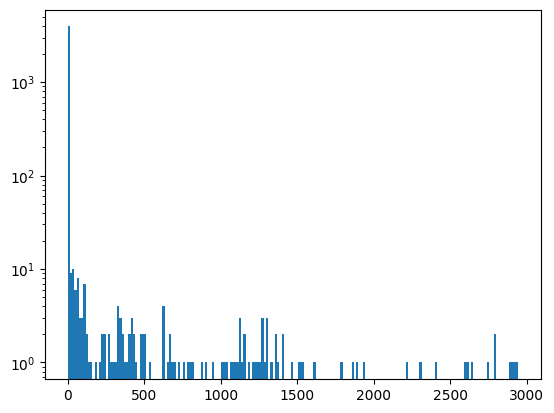

In [162]:
module_down = "attn"
layer_down = 3

num_connections = torch.zeros(4096)
for layer_up in range(layer_down):
    for module_up in ["attn", "cc"]:    
        mask = suite.module_dict[f"{module_down}_{layer_down}"].connection_masks[f'{module_up}_{layer_up}'].forward(temperature=0.0)
        num_connections += mask.sum(dim=1).float().detach().cpu()

print((num_connections == 0).sum())
print((num_connections > 0).sum())
plt.hist(num_connections.float().detach().cpu().numpy(), bins=200)
plt.yscale('log')
plt.show()

In [165]:
num_connections.topk(500)

torch.return_types.topk(
values=tensor([2.9460e+03, 2.9210e+03, 2.9060e+03, 2.9000e+03, 2.7960e+03, 2.7950e+03,
        2.7450e+03, 2.6480e+03, 2.6090e+03, 2.6060e+03, 2.4040e+03, 2.2980e+03,
        2.2130e+03, 1.9330e+03, 1.8970e+03, 1.8640e+03, 1.7950e+03, 1.6070e+03,
        1.5320e+03, 1.5290e+03, 1.5080e+03, 1.4670e+03, 1.4100e+03, 1.4100e+03,
        1.3710e+03, 1.3690e+03, 1.3580e+03, 1.3290e+03, 1.3090e+03, 1.3090e+03,
        1.3000e+03, 1.2940e+03, 1.2810e+03, 1.2720e+03, 1.2690e+03, 1.2630e+03,
        1.2460e+03, 1.2270e+03, 1.2210e+03, 1.1900e+03, 1.1620e+03, 1.1600e+03,
        1.1440e+03, 1.1330e+03, 1.1230e+03, 1.1200e+03, 1.1180e+03, 1.0950e+03,
        1.0850e+03, 1.0610e+03, 1.0350e+03, 1.0270e+03, 1.0090e+03, 9.4300e+02,
        9.0200e+02, 8.8300e+02, 8.1500e+02, 7.9900e+02, 7.8600e+02, 7.5800e+02,
        7.2400e+02, 6.9300e+02, 6.8000e+02, 6.7600e+02, 6.6700e+02, 6.5900e+02,
        6.3000e+02, 6.2500e+02, 6.2300e+02, 6.2200e+02, 5.4100e+02, 5.1100e+02,
        